In [ ]:
!pip install -qq -U adapters accelerate bitsandbytes datasets transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.4 MB/s eta 0:00:00


In [ ]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU capability:", torch.cuda.get_device_capability(0))
else:
    print("NO GPU DETECTED")

Torch version: 2.8.0+cu126
CUDA available: True
GPU name: Tesla T4
GPU capability: (7, 5)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_dataset

dataset = load_dataset("ccdv/arxiv-summarization")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

section/train-00000-of-00015.parquet:   0%|          | 0.00/230M [00:00<?, ?B/s]

section/train-00001-of-00015.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

section/train-00002-of-00015.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/203037 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6436 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6440 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'abstract'],
        num_rows: 203037
    })
    validation: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6436
    })
    test: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6440
    })
})


In [ ]:
dataset = dataset.shuffle(seed=42)

subset = dataset["train"].select(range(2000))
print("Subset size:", len(subset))

def extractPairs(example):
    return {
        "input_text": example["article"],
        "target_text": example["abstract"]
    }

subset = subset.map(extractPairs, remove_columns=subset.column_names)

Subset size: 2000


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoTokenizer
modelpath = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(modelpath)
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

In [ ]:
train_test = subset.train_test_split(test_size=0.2, seed=42)
test_valid = train_test["test"].train_test_split(test_size=0.5, seed=42)

In [ ]:
train_dataset = train_test["train"]
valid_dataset = test_valid["train"]
test_dataset  = test_valid["test"]

In [ ]:
len(train_dataset), len(valid_dataset), len(test_dataset)

(1600, 200, 200)

In [ ]:
def tokenize(batch):
    prompt = "Summarize the following scientific article:\n\n" + batch["input_text"] + "\n\nSummary: "
    full_text = prompt + batch["target_text"]

    enc = tokenizer(full_text, max_length=256, truncation=True, padding="max_length")
    labels = enc["input_ids"].copy()

    prompt_ids = tokenizer(prompt, max_length=256, truncation=True)["input_ids"]
    labels[:len(prompt_ids)] = [-100] * len(prompt_ids)

    enc["labels"] = labels
    return enc

In [ ]:
train_tokenized = train_dataset.map(tokenize, remove_columns=train_dataset.column_names)
valid_tokenized = valid_dataset.map(tokenize, remove_columns=valid_dataset.column_names)
test_tokenized  = test_dataset.map(tokenize, remove_columns=test_dataset.column_names)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForCausalLM

In [ ]:
base_model = AutoModelForCausalLM.from_pretrained(
    modelpath,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
part1Folder = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/part1"

train_tokenized.save_to_disk(f"{part1Folder}/train_tokenized")
valid_tokenized.save_to_disk(f"{part1Folder}/valid_tokenized")
test_tokenized.save_to_disk(f"{part1Folder}/test_tokenized")
base_model.save_pretrained(f"{part1Folder}/base_model")
tokenizer.save_pretrained(f"{part1Folder}/tokenizer")

print("Part1 saved to Google Drive.")

Saving the dataset (0/1 shards):   0%|          | 0/1600 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

Part1 saved to Google Drive.


#Part 2

In [ ]:
part2Folder = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/part2"

In [ ]:
from transformers import AutoModelForCausalLM
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
import torch

In [ ]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
base_model_path = f"{part1Folder}/base_model"
model = AutoModelForCausalLM.from_pretrained(
    base_model_path,
    quantization_config=bnb_config,
    device_map="auto"
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(f"{part1Folder}/tokenizer")
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
model = prepare_model_for_kbit_training(model)

In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
model = get_peft_model(model, lora_config)

In [ ]:
from datasets import load_from_disk

In [ ]:
train_tokenized = load_from_disk(f"{part1Folder}/train_tokenized")
valid_tokenized = load_from_disk(f"{part1Folder}/valid_tokenized")

In [ ]:
from transformers import DataCollatorForSeq2Seq
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

In [ ]:
from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir=f"{part2Folder}/lora_model",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=1,
    save_steps=100,
    save_total_limit=3,
    eval_strategy="epoch",
    logging_steps=50,
    bf16=True,
    report_to="none"
)

In [ ]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=valid_tokenized,
    data_collator=data_collator
)

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
print("Training on:", next(model.parameters()).device)

Training on: cuda:0


In [ ]:
trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,0.000000,nan


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

TrainOutput(global_step=400, training_loss=1.9732364654541015, metrics={'train_runtime': 1602.091, 'train_samples_per_second': 0.999, 'train_steps_per_second': 0.25, 'total_flos': 2545185875558400.0, 'train_loss': 1.9732364654541015, 'epoch': 1.0})

In [ ]:
loraPath = f"{part2Folder}/lora_model"
model.save_pretrained(loraPath, save_adapter=True)

tokenizer.save_pretrained(loraPath)
print("Part2 saved to Google Drive")

Part2 saved to Google Drive


#Part 3

In [ ]:
# Correct Part 3

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

# FIXED PATHS (Google Drive paths)
part1Folder = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/part1"
part2Folder = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/part2/lora_model"

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load base model (local only)
base_model = AutoModelForCausalLM.from_pretrained(
    f"{part1Folder}/base_model",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    local_files_only=True
)

# Load LoRA weights correctly
model = PeftModel.from_pretrained(
    base_model,
    part2Folder,
    local_files_only=True
)

# Load tokenizer (local only)
tokenizer = AutoTokenizer.from_pretrained(
    f"{part1Folder}/tokenizer",
    local_files_only=True
)
tokenizer.pad_token = tokenizer.eos_token

print("Part 3 models loaded successfully.")


Part 3 models loaded successfully.


In [ ]:
dataset = load_dataset("ccdv/arxiv-summarization")

dataset = dataset.shuffle(seed=42)
subset = dataset["test"].select(range(10))

test_inputs = [ex["article"] for ex in subset]
ground_truths = [ex["abstract"] for ex in subset]

In [ ]:
def shorten_text(text, tokenizer, max_tokens=800):
    encoded = tokenizer(text, truncation=True, max_length=max_tokens)
    return tokenizer.decode(encoded["input_ids"], skip_special_tokens=True)

def generate_summary(model, tokenizer, text, max_new_tokens=256):
    short_text = shorten_text(text, tokenizer, max_tokens=800)

    prompt = f"Summarize the following scientific article:\n\n{short_text}\n\nSummary: "

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            top_p=0.9,
            temperature=0.7
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
all_results = []

for article, target in zip(test_inputs, ground_truths):
    base_sum = generate_summary(base_model, tokenizer, article)
    lora_sum = generate_summary(model, tokenizer, article)

    all_results.append({
        "article": article,
        "ground_truth": target,
        "base": base_sum,
        "lora": lora_sum
    })

In [ ]:
!pip install -q python-docx
from docx import Document

# Create a new Word document
doc = Document()
doc.add_heading("Summarization Results", level=1)

for i, res in enumerate(all_results, 1):
    doc.add_heading(f"Sample {i}", level=2)

    doc.add_paragraph("Article:")
    doc.add_paragraph(res["article"], style='Intense Quote')

    doc.add_paragraph("Ground Truth Summary:")
    doc.add_paragraph(res["ground_truth"], style='Intense Quote')

    doc.add_paragraph("Base Model Summary:")
    doc.add_paragraph(res["base"], style='Intense Quote')

    doc.add_paragraph("LoRA Model Summary:")
    doc.add_paragraph(res["lora"], style='Intense Quote')

    doc.add_paragraph("\n" + "-"*50 + "\n")  # separator

# Save the document to Google Drive
output_path = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/test_summaries.docx"
doc.save(output_path)

print(f"Results saved to {output_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 7.4 MB/s eta 0:00:00
Results saved to /content/drive/MyDrive/tinyllama_lora_checkpoints2/test_summaries.docx


#Part 4

##A

In [ ]:
!pip install -qq rouge_score

  Preparing metadata (setup.py) ... done


In [ ]:
from rouge_score import rouge_scorer
import numpy as np

In [ ]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

In [ ]:
base_summaries = [res['base'] for res in all_results]
lora_summaries = [res['lora'] for res in all_results]
ground_truths = [res['ground_truth'] for res in all_results]

In [ ]:
def compute_rouge(predictions, references):
    rouge1_list = []
    rougeL_list = []

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        rouge1_list.append(scores['rouge1'].fmeasure)
        rougeL_list.append(scores['rougeL'].fmeasure)

    avg_scores = {
        "ROUGE-1": np.mean(rouge1_list),
        "ROUGE-L": np.mean(rougeL_list)
    }
    return avg_scores

In [ ]:
base_rouge = compute_rouge(base_summaries, ground_truths)
lora_rouge = compute_rouge(lora_summaries, ground_truths)

In [ ]:
!pip install -qq nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [ ]:
smooth = SmoothingFunction().method1

In [ ]:
def compute_bleu(predictions, references):
    scores = []
    for pred, ref in zip(predictions, references):
        ref_tokens = ref.split()
        pred_tokens = pred.split()
        score = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth)
        scores.append(score)
    return np.mean(scores)

In [ ]:
base_bleu = compute_bleu(base_summaries, ground_truths)
lora_bleu = compute_bleu(lora_summaries, ground_truths)

In [ ]:
!pip install -qq bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
from bert_score import score as bert_score

In [ ]:
P, R, F1 = bert_score(base_summaries, ground_truths, lang="en", rescale_with_baseline=True)
base_bertscore = F1.mean().item()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
P, R, F1 = bert_score(lora_summaries, ground_truths, lang="en", rescale_with_baseline=True)
lora_bertscore = F1.mean().item()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
print("ROUGE Scores (Base TinyLlama):", base_rouge)
print("ROUGE Scores (LoRA Fine-Tuned):", lora_rouge)

ROUGE Scores (Base TinyLlama): {'ROUGE-1': np.float64(0.28833799450996506), 'ROUGE-L': np.float64(0.15477075014573133)}
ROUGE Scores (LoRA Fine-Tuned): {'ROUGE-1': np.float64(0.29761116006201327), 'ROUGE-L': np.float64(0.15863922130987745)}


In [ ]:
print("BLEU Scores (Base TinyLlama):", base_bleu)
print("BLEU Scores (LoRA Fine-Tuned):", lora_bleu)

BLEU Scores (Base TinyLlama): 0.05416498008944233
BLEU Scores (LoRA Fine-Tuned): 0.057835438654162755


In [ ]:
print("BERTScore (Base TinyLlama):", base_bertscore)
print("BERTScore (LoRA Fine-Tuned):", lora_bertscore)

BERTScore (Base TinyLlama): 0.0389566570520401
BERTScore (LoRA Fine-Tuned): 0.0389566570520401


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

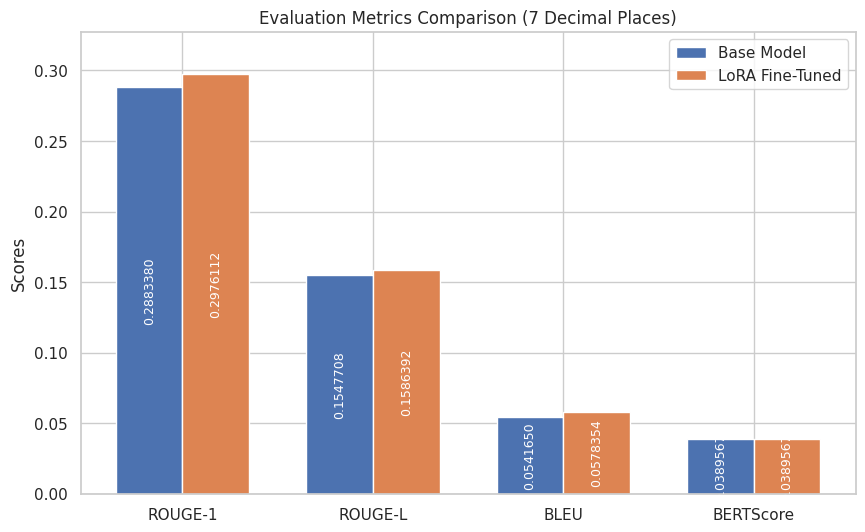

In [ ]:
import numpy as np

sns.set(style="whitegrid")

metrics = ["ROUGE-1", "ROUGE-L", "BLEU", "BERTScore"]
base_scores = [base_rouge["ROUGE-1"], base_rouge["ROUGE-L"], base_bleu, base_bertscore]
lora_scores = [lora_rouge["ROUGE-1"], lora_rouge["ROUGE-L"], lora_bleu, lora_bertscore]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar(x - width/2, base_scores, width, label='Base Model')
rects2 = ax.bar(x + width/2, lora_scores, width, label='LoRA Fine-Tuned')

ax.set_ylabel("Scores")
ax.set_title("Evaluation Metrics Comparison (7 Decimal Places)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, max(max(base_scores), max(lora_scores)) * 1.1)
ax.legend()

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width()/2,
            height/2,
            f'{height:.7f}',
            ha='center', va='center', rotation=90, fontsize=9, color='white'
        )

plt.show()


In [ ]:
import torch
import os

# Folder to save Part 4A variables
part4AFolder = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/part4/A"
os.makedirs(part4AFolder, exist_ok=True)

# Save all important variables from Part 4A
torch.save(base_rouge, f"{part4AFolder}/base_rouge.pt")
torch.save(lora_rouge, f"{part4AFolder}/lora_rouge.pt")
torch.save(base_bleu, f"{part4AFolder}/base_bleu.pt")
torch.save(lora_bleu, f"{part4AFolder}/lora_bleu.pt")
torch.save(base_bertscore, f"{part4AFolder}/base_bertscore.pt")
torch.save(lora_bertscore, f"{part4AFolder}/lora_bertscore.pt")
torch.save(base_scores, f"{part4AFolder}/base_scores.pt")
torch.save(lora_scores, f"{part4AFolder}/lora_scores.pt")

print("Part 4A variables saved")


Part 4A variables saved


#B

In [ ]:
part1AFolder = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/part1"
part2AFolder = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/part2"
part4AFolder = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/part4/A"
part3Folder = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/test_summaries.docx"

In [ ]:
!pip install -qq transformers huggingface_hub

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from huggingface_hub import InferenceClient

In [ ]:
import torch
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from docx import Document

part3Folder = "/content/drive/MyDrive/tinyllama_lora_checkpoints2/test_summaries.docx"
doc = Document(part3Folder)

# Extract text sample by sample
samples = []
current_sample = {}
section = None

for para in doc.paragraphs:
    text = para.text.strip()
    if text.startswith("Sample"):
        if current_sample:
            samples.append(current_sample)
        current_sample = {"article": "", "ground_truth": "", "base": "", "lora": ""}
        section = None
    elif text.startswith("Article:"):
        section = "article"
    elif text.startswith("Ground Truth Summary:"):
        section = "ground_truth"
    elif text.startswith("Base Model Summary:"):
        section = "base"
    elif text.startswith("LoRA Model Summary:"):
        section = "lora"
    elif section and text:
        current_sample[section] += text + "\n"

if current_sample:
    samples.append(current_sample)

print(f"Loaded {len(samples)} samples")

Loaded 10 samples


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-large"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = "cpu"
model.to(device)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 1024)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=1024, out_features=1024, bias=False)
              (k): Linear(in_features=1024, out_features=1024, bias=False)
              (v): Linear(in_features=1024, out_features=1024, bias=False)
              (o): Linear(in_features=1024, out_features=1024, bias=False)
              (relative_attention_bias): Embedding(32, 16)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=1024, out_features=2816, bias=False)
              (wi_1): Linear(in_features=1024, out_features=2816, bias=False)
       

In [ ]:
def evaluate_summary(article, reference_summary, model_summary):
    prompt = f"""
You will now act as as a judge. Your role is to serve as an automated evaluator of summaries and rate
each summary on a scale of 1 to 5 on the following three dimensions

1. Fluency: Is the summary readable and grammatically correct?
2. Factuality: Are the statements in the summary correct, and do they reflect the source?
3. Coverage: Does the summary include the main problem, method, and key findings?

And then you should give a short justification for each score


Article: {article[:3000]}

Reference Summary: {reference_summary}

Generated Summary: {model_summary}
"""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(device)
    outputs = model.generate(**inputs, max_new_tokens=200)
    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return result

for i, sample in enumerate(samples[:10], 1):
    article = sample["article"]
    reference_summary = sample["ground_truth"]
    model_summary = sample["lora"]  # or "base"

    print(f"\nEvaluation for Sample {i}\n")
    result = evaluate_summary(article, reference_summary, model_summary)
    print(result)


Evaluation for Sample 1

the ever increasing availability of digital traces of human actions is widely enabling the representation and the analysis of massive amounts of information on human behavior .

Evaluation for Sample 2

1

Evaluation for Sample 3

1

Evaluation for Sample 4

4

Evaluation for Sample 5

multiple scattering can affect the extinction laws of astronomical objects

Evaluation for Sample 6

4

Evaluation for Sample 7

4

Evaluation for Sample 8

4

Evaluation for Sample 9

4

Evaluation for Sample 10

1
